# Estatística para analistas de dados

In [111]:
import pandas as pd
import math as mt

In [112]:
pd.__version__ # Obter varsão pandas

'2.3.3'

## Definindo dados

In [113]:
dict_metrics = {"idade" : [14, 20, 44, 21, 20, 45, 21, 9],
                "altura" : [160, 120, 181, 210, 120, 165, 181, 178]
                }
type(dict_metrics)

dict

In [114]:
df = pd.DataFrame(dict_metrics)
df.head(10)

,idade,altura
0,14,160
1,20,120
2,44,181
3,21,210
4,20,120
5,45,165
6,21,181
7,9,178


## Medidas de posição

### Medidas de têndencia central

- Média: Soma de valores pelo número de valores.

- Mediana: Valor do meio em uma lista ordenada.

- Moda: Valor que mais se repete.


In [115]:
# Média
media_idade = df["idade"].mean()
media_altura = df["altura"].mean()

print(f"A média de idade é {media_idade}\nA média de altura é {media_altura}")

A média de idade é 24.25
A média de altura é 164.375


In [116]:
# Mediana
mediana_idade = df["idade"].median()
mediana_altura = df["altura"].median()

print(f"A mediana de idade é {mediana_idade}\nA mediana de altura é {mediana_altura}")

A mediana de idade é 20.5
A mediana de altura é 171.5


In [117]:
moda_idade = df["idade"].mode()
moda_atura = df["altura"].mode()

print(f"A moda de idade é {moda_idade}\nA moda de altura é {moda_atura}")

A moda de idade é 0    20
1    21
Name: idade, dtype: int64
A moda de altura é 0    120
1    181
Name: altura, dtype: int64


### Medidas de dispersão

- Variância: É a média dos quadrados entre cada valor e a média. Informa quão distantes os valores estão distantes de média.

- Desvio padrão: É a raiz quadrada da variãncia. expressa a disperção dos termos da mesma unidade.

- Coeficiente de variação : O desvio padrão dividido pela média e é expresso pela média. indica a variabilidade relativa dos dados em relação a média.

In [118]:
print(f"A variância da idade é {df['idade'].var()}")
print(f"A variância altura é {df['altura'].var()}")

A variância da idade é 173.64285714285714
A variância altura é 968.2678571428571


In [119]:
# Usando o sqrt
print(f"O desvio padrão da idada é {mt.sqrt(df['idade'].var())}")
print(f"O desvio padrão da idada é {mt.sqrt(df['altura'].var())}")

# STD para desvio padrão

print(f"O desvio padrão da idada é {df['idade'].std()}") 
print(f"O desvio padrão da idada é {df['altura'].std()}")

O desvio padrão da idada é 13.177361539506197
O desvio padrão da idada é 31.11700270178439
O desvio padrão da idada é 13.177361539506197
O desvio padrão da idada é 31.11700270178439


In [120]:
def coefv(df):
    cofv =  round( ((df.std()/df.mean())*100),2)
    cofvp = cofv.astype(str).replace(".", ",") + "%"
    return cofvp

print(f"O coeficiênte de variância {coefv(df['idade'])}")
print(f"O coeficiênte de variância {coefv(df['altura'])}")

O coeficiênte de variância 54,34%
O coeficiênte de variância 18,93%


### Medidas de Forma (Distribuição dos dados)

- Assimetrica: Indica o gral de direção das distorção da distribuição em relação a média, se positiva calda direita da distribuição mais longa e vice versa.

- Curtose: Mede o pico ou pontuação da distribuição. Isso indica que quanto maior o pico ou pontuação da curtose com a distribuição maior será a concentração dos dados e vice versa. 

In [121]:
# A assimétria de idade foi positiva pois as maiores idades estão próximas
print(f"Assimetria de idade é {df['idade'].skew()}")

# A assimétria de altura foi negativa pois os maiores valores estão distântes 
print(f"Assimetria de idade é {df['altura'].skew()}")

Assimetria de idade é 0.9816394188527026
Assimetria de idade é -0.4308406470833072


In [122]:
print(f"curtose de idade é {df['idade'].kurtosis()}")
print(f"curtose de altura é {df['altura'].kurtosis()}")

curtose de idade é -0.3114313421473396
curtose de altura é -0.410743240720123


In [123]:
# Usando o describe para estatísticas acerca dem coluna em específico
df['idade'].describe()

count     8.000000
mean     24.250000
std      13.177362
min       9.000000
25%      18.500000
50%      20.500000
75%      26.750000
max      45.000000
Name: idade, dtype: float64

In [124]:
# Usando o describe para estatísticas acerca dem coluna em específico
df.describe()

,idade,altura
count,8.000000,8.000000
mean,24.250000,164.375000
std,13.177362,31.117003
min,9.000000,120.000000
25%,18.500000,150.000000
50%,20.500000,171.500000
75%,26.750000,181.000000
max,45.000000,210.000000


### Correlação

- varía de -1 a 1.

- quanto mais próximas dos extremos mais correlação elas possuem, seja uma correlação positiva (quando uma cresce a outra também cresce) ou negativa (quando uma cresce a outra diminue).

- Quanto mais próximo de 0 menos correlação possue.

- Ajuda a selecionar variáveis relevantes para para aprendizagem de máquina 

In [125]:
correl =  df['idade'].corr(df['altura'], method='pearson') # Por padrão o corr (função para a correlação de variáveis) sempres usara a corrlação de linear de Person para valores contínuos
print(f"A correlação entre idade e altura é igual a {correl}")

A correlação entre idade e altura é igual a 0.123071618319004


In [126]:
df.corr(method='pearson') # Correlação linear de Person para valores contínuos 

,idade,altura
idade,1.000000,0.123072
altura,0.123072,1.000000


In [127]:
df.corr(method='spearman') # Correlação não linear para valores ordinais ou com outliers

,idade,altura
idade,1.000000,0.408537
altura,0.408537,1.000000


## Visualização de dados

In [128]:
import matplotlib as plt

In [129]:
df.head(10)

,idade,altura
0,14,160
1,20,120
2,44,181
3,21,210
4,20,120
5,45,165
6,21,181
7,9,178


### Gráfico de Histograma

<Axes: >

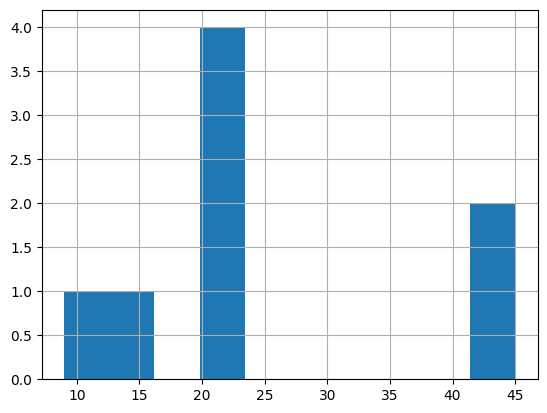

In [130]:
df['idade'].hist()

<Axes: >

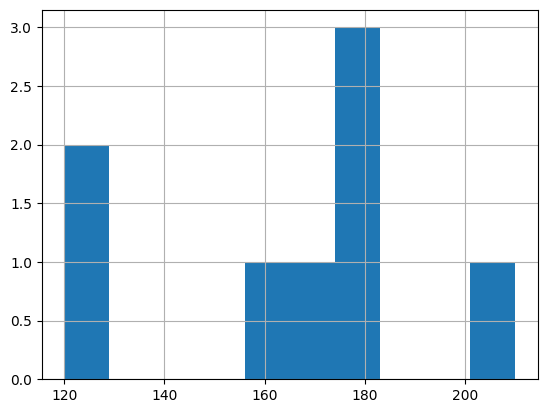

In [131]:
df['altura'].hist()

### Gráfico de BoxPlot

<Axes: >

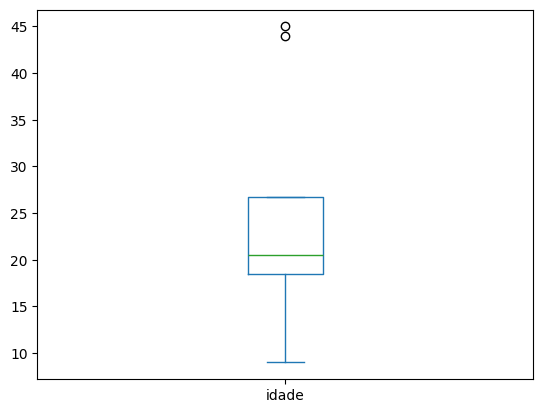

In [132]:
df['idade'].plot.box()

<Axes: >

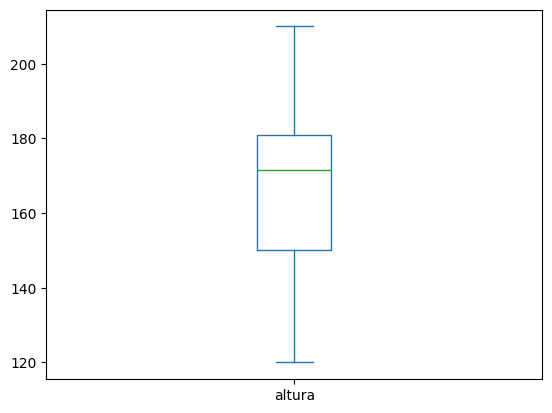

In [133]:
df['altura'].plot.box()

In [136]:
# Verificando coeficiente de correlação
print(df['altura'].mean())
print((df['altura'].std()/df['altura'].mean()) * 100)

164.375
18.93049594024906


### Gráfico de Dispersão

In [ ]:
correlacao_idade_altura = df['idade'].corr(df['altura'], method='pearson')

print(round(correlacao_idade_altura, 2)) # resultado: 0.12 é uma correlação fraca

0.12


<Axes: xlabel='idade', ylabel='altura'>

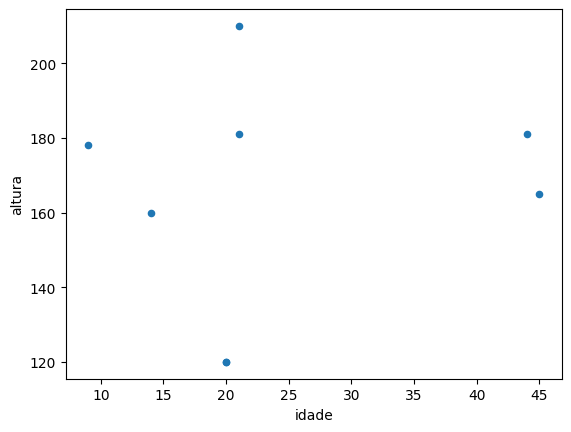

In [ ]:
df.plot.scatter(x='idade', y='altura') # Interessante, não a correlação das variáveis de interesse 

### Teste pessoal

In [148]:
dic = {
    'idade' : [20,30,40,50,60],
    'salario' : [1800, 3900, 4900, 6200, 8000]
}
df2 = pd.DataFrame(dic)
df2['idade'].corr(df2['salario'], method='pearson')

np.float64(0.9935154268272273)

<Axes: >

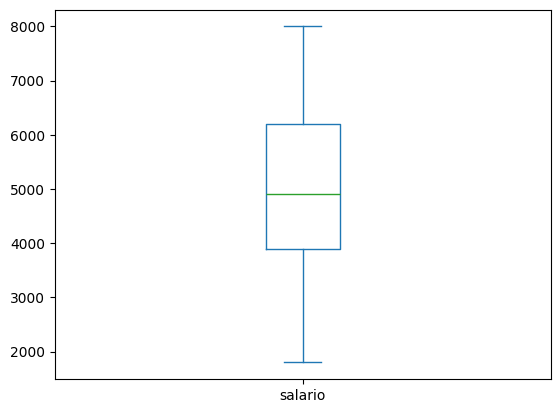

In [149]:
df2['salario'].plot.box()

<Axes: xlabel='idade', ylabel='salario'>

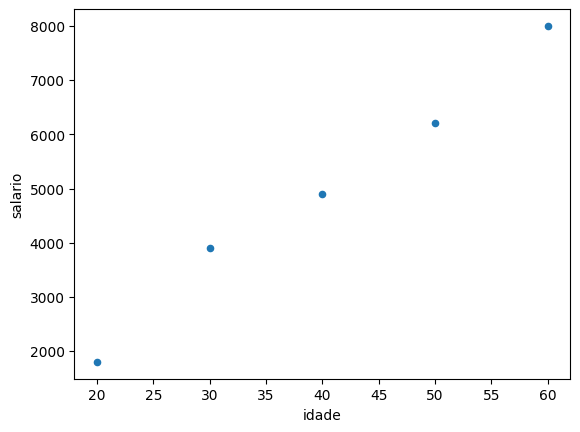

In [150]:
df2.plot.scatter(x='idade', y='salario')

Resumo sobre sobre os gráfico de disperção: KKKKK, gostei muito pois tinha digitado um valor com um 0 a mais sem peceber e antes de gerar o gráfico quis teste a correlação com o corr, o resultado foi desastroso, kkkkkk. Então plotei o scatter e box e achei o espertinho! um outlier tão grande que distorcel completamente os meus dados. Foi uma boa caçada !

### Gráfico de Barras